# Derivation of Crowell and Labuda for Special Cases using SymPy

## Detector Comparison: CMOS, CCD, and MCT

This table groups imaging detectors by their physical architecture, light-entry geometry, and the resulting internal layer logic.

| Detector Category | Architecture | Geometry (Light Path) | Internal Layer Order | Core Assumption / Key Feature |
| :--- | :--- | :--- | :--- | :--- |
| **Standard CMOS** | **FSI** (Front-Illuminated) | Light hits circuitry side first. | **Depletion → Field-Free** | **Shadowing:** Metal wiring reduces fill factor; requires microlenses to focus light. |
| **Scientific CMOS (sCMOS)** | **BSI** (Back-Illuminated) | Light hits thinned silicon substrate. | **Field-Free → Depletion** | **Diffusion:** Uses **PPD** (Pinned Photodiode) and **DTI** (Deep Trench Isolation) to prevent crosstalk. |
| **Standard CCD** | **FSI** (Front-Illuminated) | Light hits polysilicon gate electrodes. | **Depletion → Field-Free** | **Charge Transfer:** High **CTE** is required to move charge across the chip without "smearing." |
| **Scientific CCD** | **BSI** (Back-Illuminated) | Light hits thinned back-surface. | **Field-Free → Depletion** | **Thinning:** Wafer is thinned (<20 µm) so electrons don't wander before hitting the depletion zone. |
| **Deep Depletion CCD** | **Thick-Substrate** | High-bias voltage applied. | **Fully Depleted** (No Field-Free) | **High Energy:** Eliminates the field-free region entirely to capture NIR or X-ray photons accurately. |
| **MCT (Infrared)** | **Hybrid / BSI** | Light hits MCT absorber layer. | **Field-Free → Depletion** | **Hybridization:** Detector material is bump-bonded to a Silicon **ROIC** (Readout Integrated Circuit). |

Key Definitions:

* **Field-Free (Neutral) Region:** A region with no internal electric field where electrons move via slow, random diffusion.
* **Depletion Region:** A region with a strong electric field that "sweeps" electrons toward the storage well instantly.
* **PPD (Pinned Photodiode):** A structure that "pins" the surface potential to reduce dark current and eliminate "image lag."
* **DTI (Deep Trench Isolation):** Physical "trenches" etched between pixels to prevent electrons in the field-free region from drifting into adjacent pixels.

### Notes on C&L Applicability

- **BSI detectors** (sCMOS, Scientific CCD, MCT) match the **C&L geometry**: light enters the field-free region first, then reaches depletion. These are the primary targets for the C&L model.
- **FSI detectors** (Standard CMOS, Standard CCD) have **reversed geometry**: light enters the depletion region first. The C&L equation does not directly apply — a reversed-geometry derivation from first principles is needed.
- **Deep Depletion CCD** has no field-free region, so diffusion MTF is unity (no degradation).
- For Scientific CCD, the **dead back surface** ($S \to \infty$) is a key concern — this maps directly to Case 1.

### Detector → C&L Parameter Mapping and Derivation Cases

| Detector Type | Light Direction | $S$ | $R$ | $L_b$ | Case Number |
|---|---|---|---|---|---|
| Scientific CCD (BSI, thinned) | Field-Free → Depletion | $S \to \infty$ | $R = 0$ | finite | Case 1 |
| sCMOS (BSI, passivated) | Field-Free → Depletion | $S \approx 0$ | $R = 0$ | finite | Case 2|
| MCT Infrared (BSI, thick) | Field-Free → Depletion | finite $S$ | $R \approx 0$ | $L_b \to \infty$ | Case 3 |
| Deep Depletion CCD | Fully Depleted | — | — | — | No field-free → MTF = 1 |
| FSI (CMOS/CCD) | Depletion → Field-Free | finite $S$ | $R = 0$ | finite | Reversed geometry |

**Note on light direction:** The original C&L model derives the diffusion equation for light entering the field-free region first (BSI geometry). For FSI detectors, where light enters the depletion region first, the generation profile in the field-free region changes and the boundary conditions are different. Both directions must be derived from the diffusion equation.

## Crowell and Labuda Diffusion MTF Model

The most general analytical diffusion MTF model, from the original Crowell & Labuda (1969) paper "The Silicon Diode Array Camera Tube" (BSTJ Vol. 48, No. 5, Eq. 5).

**Geometry** (Fig. 3 in the paper): Light enters at $y = 0$ (illuminated surface), passes through the undepleted field-free region ($0 \le y \le L_a$), and reaches the depletion region edge at $y = L_a$. The total n-type region extends to $y = L_b$, so the depletion width is $L_b - L_a$.

**Boundary conditions** (Eq. 2):
- At $y = 0$ (illuminated surface): $S p = D \frac{\partial p}{\partial y}$ (surface recombination)
- At $y = L_a$ (depletion edge): $p = 0$ (carriers swept away by E-field)

**Generation** (Eq. 3): $G(x, y) = \frac{N_0}{2} \alpha (1 - R)(1 + \cos kx) e^{-\alpha y}$

where $R$ is the back-surface reflectivity and $k = 2\pi f$ is the spatial frequency.

The collection efficiency at spatial frequency $k$ is given by **Eq. (5)**:

$$\eta_k = \frac{\alpha L (1 - R)}{\alpha^2 L^2 - 1} \left[ \frac{2(\alpha L + SL/D) - (\beta_+ - \beta_-) \exp(-\alpha L_a)}{\beta_+ + \beta_-} - (\alpha L)^{-1} \exp(-\alpha L_a) \right] - (1 - R) \exp(-\alpha L_b)$$

where:
- $\beta_{\pm} = (1 \pm SL/D) \exp(\pm L_a / L)$
- $1/L^2(k) = 1/L_o^2 + k^2$ (so $L(k) = L_o / \sqrt{1 + (2\pi f L_o)^2}$, our $L_f$)
- $L_o = \sqrt{D \tau}$ is the diffusion length
- $L_a$ = undepleted (field-free) region thickness
- $L_b$ = total n-type region thickness ($L_b - L_a$ = depletion width)
- $S$ = surface recombination velocity at the illuminated surface (cm/s)
- $D$ = minority carrier diffusion coefficient (cm<sup>2</sup>/s)
- $R$ = back-surface reflectivity

The diffusion MTF is: $R_D(k) = \eta_k / \eta_0$

**Note on the last term**: The $-(1-R)\exp(-\alpha L_b)$ term accounts for photons that traverse the entire substrate without being absorbed. For thick substrates ($\alpha L_b \gg 1$), this term is negligible.

### C&L Equation in SymPy

In [35]:
import sympy as sp

# Define symbols
alpha = sp.Symbol("alpha", positive=True)  # absorption coefficient [1/length]
k = sp.Symbol("k", nonnegative=True)  # spatial frequency [rad/length]
L_o = sp.Symbol("L_o", positive=True)  # zero-frequency diffusion length
L_a = sp.Symbol("L_a", positive=True)  # field-free (undepleted) region thickness
L_b = sp.Symbol("L_b", positive=True)  # total substrate thickness (L_b > L_a)
S = sp.Symbol("S", nonnegative=True)  # surface recombination velocity
D = sp.Symbol("D", positive=True)  # minority carrier diffusion coefficient
R = sp.Symbol("R", nonnegative=True)  # back-surface reflectivity (0 <= R <= 1)

# Frequency-dependent diffusion length  L(k) = L_o / sqrt(1 + k^2 * L_o^2)
L = L_o / sp.sqrt(1 + k**2 * L_o**2)

# Dimensionless groups
aL = alpha * L  # alpha * L(k)
sLD = S * L / D  # S*L/D  (dimensionless surface recombination term)

# beta_+/-  (Eq. 5 of Crowell & Labuda 1969)
beta_p = (1 + sLD) * sp.exp(L_a / L)
beta_m = (1 - sLD) * sp.exp(-L_a / L)

# Bracket numerator and denominator
bracket_num = 2 * (aL + sLD) - (beta_p - beta_m) * sp.exp(-alpha * L_a)
bracket_den = beta_p + beta_m

# Full C&L collection efficiency eta_k  (Eq. 5)
eta_k = alpha * L * (1 - R) / (alpha**2 * L**2 - 1) * (
    bracket_num / bracket_den - sp.exp(-alpha * L_a) / (alpha * L)
) - (1 - R) * sp.exp(-alpha * L_b)

print("eta_k defined. Symbols:", eta_k.free_symbols)

eta_k defined. Symbols: {alpha, D, L_o, S, k, R, L_b, L_a}


Check $\beta_+$, $\beta_-$ and the bracket before looking at $\eta_k$ in full.

In [ ]:
sp.init_printing(use_unicode=True)

print("β₊ =")
display(beta_p)
print("β₋ =")
display(beta_m)
print("β₊ + β₋ =")
display(sp.simplify(beta_p + beta_m))
print("β₊ - β₋ =")
display(sp.simplify(beta_p - beta_m))

Note that $\beta_+ + \beta_-$ and $\beta_+ - \beta_-$ can be rewritten using hyperbolic functions:

$$\beta_+ + \beta_- = 2\cosh\!\left(\frac{L_a}{L}\right) + 2\frac{SL}{D}\sinh\!\left(\frac{L_a}{L}\right)$$

$$\beta_+ - \beta_- = 2\sinh\!\left(\frac{L_a}{L}\right) + 2\frac{SL}{D}\cosh\!\left(\frac{L_a}{L}\right)$$

This is a cleaner form that we can verify below.

In [37]:
# Rewrite beta sums using hyperbolic functions and verify they are equivalent
xi = L_a / L  # shorthand for L_a / L(k)

beta_sum_hyp = 2 * sp.cosh(xi) + 2 * sLD * sp.sinh(xi)
beta_diff_hyp = 2 * sp.sinh(xi) + 2 * sLD * sp.cosh(xi)

# Verify identities (should be zero)
check_sum = sp.simplify(
    (beta_p + beta_m).rewrite(sp.exp) - beta_sum_hyp.rewrite(sp.exp)
)
check_diff = sp.simplify(
    (beta_p - beta_m).rewrite(sp.exp) - beta_diff_hyp.rewrite(sp.exp)
)
print("β₊ + β₋  check (should be 0):", check_sum)
print("β₊ - β₋  check (should be 0):", check_diff)

β₊ + β₋  check (should be 0): 0
β₊ - β₋  check (should be 0): 0


### Full $\eta_k$ in hyperbolic form

Substituting the hyperbolic identities, the bracket ratio becomes:

$$\frac{\beta_+ - \beta_-}{\beta_+ + \beta_-} = \frac{\sinh(L_a/L) + (SL/D)\cosh(L_a/L)}{\cosh(L_a/L) + (SL/D)\sinh(L_a/L)}$$

and the full collection efficiency is:

$$\eta_k = \frac{\alpha L (1-R)}{\alpha^2 L^2 - 1} \left[ \frac{2(\alpha L + SL/D) - \left[2\sinh\!\frac{L_a}{L} + 2\frac{SL}{D}\cosh\!\frac{L_a}{L}\right]e^{-\alpha L_a}}{2\cosh\!\frac{L_a}{L} + 2\frac{SL}{D}\sinh\!\frac{L_a}{L}} - \frac{e^{-\alpha L_a}}{\alpha L} \right] - (1-R)\,e^{-\alpha L_b}$$

In [38]:
# Rewrite eta_k using hyperbolic form and verify equivalence
eta_k_hyp = alpha * L * (1 - R) / (alpha**2 * L**2 - 1) * (
    (2 * (aL + sLD) - beta_diff_hyp * sp.exp(-alpha * L_a)) / beta_sum_hyp
    - sp.exp(-alpha * L_a) / (alpha * L)
) - (1 - R) * sp.exp(-alpha * L_b)

# Verify equivalence with the original exponential form
check_eta = sp.simplify(eta_k.rewrite(sp.exp) - eta_k_hyp.rewrite(sp.exp))
print("eta_k equivalence check (should be 0):", check_eta)

eta_k equivalence check (should be 0): 0


## Reversed Geometry: FSI (Depletion → Field-Free)

For **front-side illuminated (FSI)** detectors (Standard CMOS, Standard CCD), light enters the depletion region first, then reaches the field-free region. We derive the collection efficiency from the diffusion equation.

### Geometry

- Light enters at $z = 0$ (illuminated surface / depletion region edge)
- Depletion region: $0 \le z \le L_D$ (carriers collected instantly, no diffusion)
- Field-free region: $L_D \le z \le L_D + L_a$ (carriers diffuse)
- Far surface at $z = L_D + L_a$ with surface recombination velocity $S$

We define a local coordinate $y$ within the field-free region: $y = z - L_D$, so $0 \le y \le L_a$.

### Differences from the original C&L (BSI) model

| | **C&L / BSI** (Field-Free → Depletion) | **Reversed / FSI** (Depletion → Field-Free) |
|---|---|---|
| **BC at $y = 0$** | Surface recombination: $Sp = D \frac{\partial p}{\partial y}$ | Depletion edge: $p = 0$ |
| **BC at $y = L_a$** | Depletion edge: $p = 0$ | Surface recombination: $-D \frac{\partial p}{\partial y} = Sp$ |
| **Generation** | $G \propto \alpha\, e^{-\alpha y}$ (full intensity) | $G \propto \alpha\, e^{-\alpha L_D}\, e^{-\alpha y}$ (attenuated by depletion) |
| **Depletion collection** | Included via back-surface term | Separate term: $\eta_{\text{dep}} = 1 - e^{-\alpha L_D}$ |
| **Back-surface reflection** | $R$ can be nonzero | $R = 0$ (photons exit through back) |
| **Collection current** | Diffusion current at $y = L_a$ (depletion edge) | Diffusion current at $y = 0$ (depletion edge) |

Note the sign convention change for the surface recombination BC: at $y = L_a$ the outward normal is $+y$, so the flux into the surface is $-D \frac{\partial p}{\partial y}$.

### Simplification: Dead far surface ($S \to \infty$)

For standard FSI detectors, the far surface (back of the substrate) typically has very high recombination ($S \to \infty$), giving the simpler BC:

- At $y = 0$: $p = 0$ (depletion edge)
- At $y = L_a$: $p = 0$ (dead far surface)

### Diffusion equation

$$\frac{d^2 p_k}{dy^2} - \frac{p_k}{L^2} = -\frac{\alpha}{D}\, e^{-\alpha L_D}\, e^{-\alpha y}$$

The general solution is:

$$p_k(y) = A \sinh\!\frac{y}{L} + B \cosh\!\frac{y}{L} + P\, e^{-\alpha y}$$

where $P = \frac{\alpha L^2}{D(\alpha^2 L^2 - 1)} e^{-\alpha L_D}$.

**BC1** ($p(0) = 0$): $B = -P$

**BC2** ($p(L_a) = 0$): $A \sinh\xi + B \cosh\xi + P e^{-\alpha L_a} = 0$, giving:

$$A = P\,\frac{\cosh\xi - e^{-\alpha L_a}}{\sinh\xi}$$

where $\xi = L_a/L$.

### Collection efficiency

The diffusion current at the depletion edge ($y = 0$) gives the field-free contribution:

$$\eta_{\text{ff},k} = -D \frac{dp_k}{dy}\bigg|_{y=0} = -D\left(\frac{A}{L} - \alpha P\right)$$

The total collection efficiency is:

$$\eta_k^{\text{rev}} = \underbrace{(1 - e^{-\alpha L_D})}_{\text{depletion}} + \eta_{\text{ff},k}$$

Field-free collection eta_ff (reversed, S->inf):


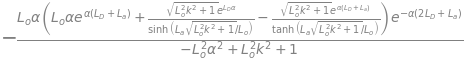


Verification vs closed form (should be 0): 0


In [39]:
# --- Reversed geometry (FSI), S -> inf: p(0) = 0, p(L_a) = 0 ---

y = sp.Symbol("y", nonneg=True)
L_D = sp.Symbol("L_D", positive=True)

xi = L_a / L

# Particular solution coefficient
P_coeff = alpha * L**2 / (D * (alpha**2 * L**2 - 1)) * sp.exp(-alpha * L_D)

# BC1: p(0) = 0  =>  B = -P
# BC2: p(L_a) = 0  =>  A = P * (cosh(xi) - exp(-alpha*L_a)) / sinh(xi)
A_coeff = P_coeff * (sp.cosh(xi) - sp.exp(-alpha * L_a)) / sp.sinh(xi)

# Collection: J = -D * (A/L - alpha*P)  at y=0
J_diff_0_rev = -D * (A_coeff / L - alpha * P_coeff)
J_diff_0_rev = sp.simplify(J_diff_0_rev)

print("Field-free collection eta_ff (reversed, S->inf):")
display(J_diff_0_rev)

# Verify the closed-form from the markdown
eta_ff_expected = (
    alpha
    * L
    * sp.exp(-alpha * L_D)
    / (alpha**2 * L**2 - 1)
    * (alpha * L - (sp.cosh(xi) - sp.exp(-alpha * L_a)) / sp.sinh(xi))
)

check = sp.simplify((J_diff_0_rev - eta_ff_expected).rewrite(sp.exp))
print("\nVerification vs closed form (should be 0):", check)

Total collection efficiency eta_k (reversed, S->inf):


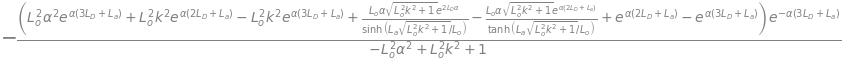

MTF(k=0) check (should be 1): 1


In [40]:
# Total collection efficiency and MTF (reversed geometry, S->inf)
eta_dep = 1 - sp.exp(-alpha * L_D)
eta_total_k_rev = sp.simplify(eta_dep + J_diff_0_rev)

print("Total collection efficiency eta_k (reversed, S->inf):")
display(eta_total_k_rev)

# Diffusion MTF: MTF(k) = eta_total_k / eta_total_0
eta_total_0_rev = eta_total_k_rev.subs(k, 0)
check_mtf0 = sp.simplify((eta_total_k_rev / eta_total_0_rev).subs(k, 0).rewrite(sp.exp))
print("MTF(k=0) check (should be 1):", check_mtf0)

## Simplifications

### Case 1: Dead Illuminated Surface + No Back-Surface Reflection

This is the Stanford / El Gamal (EE392B) special case of Crowell & Labuda.

**Physical meaning of the two assumptions:**

| Assumption | Parameter change | Physical meaning |
|---|---|---|
| Dead illuminated surface | $S \to \infty$ | Every minority carrier reaching $y=0$ recombines instantly. The surface is a perfect sink, so the minority carrier density vanishes there: $p(0)=0$. |
| No back-surface reflection | $R = 0$ | Photons that reach the back of the substrate ($y = L_b$) are fully absorbed or transmitted — none are reflected back into the field-free region. |

**Effect on $\beta_\pm$ as $S \to \infty$:** The $SL/D \to \infty$ term dominates $\pm 1$ inside $\beta_\pm$, so using the hyperbolic forms:

$$\beta_+ + \beta_- = 2\cosh\!\frac{L_a}{L} + 2\frac{SL}{D}\sinh\!\frac{L_a}{L} \;\xrightarrow{S\to\infty}\; 2\frac{SL}{D}\sinh\!\frac{L_a}{L}$$

$$\beta_+ - \beta_- = 2\sinh\!\frac{L_a}{L} + 2\frac{SL}{D}\cosh\!\frac{L_a}{L} \;\xrightarrow{S\to\infty}\; 2\frac{SL}{D}\cosh\!\frac{L_a}{L}$$

The $SL/D$ factors cancel in the ratio, leaving $\coth(L_a/L)$.

In the numerator, $2(\alpha L + SL/D) \xrightarrow{S\to\infty} 2\,SL/D$, which when divided by $2\,(SL/D)\sinh(L_a/L)$ gives $1/\sinh(L_a/L)$.

The simplified collection efficiency (verified by SymPy below) is:

$$\boxed{\eta_k^{\rm SE} = \frac{\alpha L}{\alpha^2 L^2 - 1} \left[ \frac{1}{\sinh(L_a/L)} - \coth\!\frac{L_a}{L}\cdot e^{-\alpha L_a} - \frac{e^{-\alpha L_a}}{\alpha L} \right] - e^{-\alpha L_b}}$$

or,

$$\boxed{\eta_k^{\rm SE} = \frac{\alpha L}{\alpha^2 L^2 - 1} \left[ \frac{1 - \cosh(L_a/L) \cdot e^{-\alpha L_a}}{\sinh(L_a/L)} - \frac{e^{-\alpha L_a}}{\alpha L} \right] - e^{-\alpha L_b}}$$

where $L = L_o/\sqrt{1 + k^2 L_o^2}$ as before.

eta_k (S->inf, R=0):


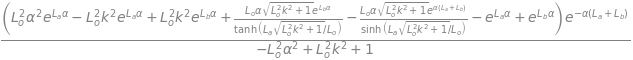


Verification vs boxed formula (should be 0): 0


In [41]:
# Apply S -> inf and R = 0 to eta_k_hyp (hyperbolic form is cleaner for this limit)
eta_k_SE = sp.limit(eta_k_hyp.subs(R, 0), S, sp.oo)
eta_k_SE = sp.simplify(eta_k_SE)
print("eta_k (S->inf, R=0):")
display(eta_k_SE)

# Verify against the merged boxed formula
eta_k_SE_expected = alpha * L / (alpha**2 * L**2 - 1) * (
    (1 - sp.cosh(xi) * sp.exp(-alpha * L_a)) / sp.sinh(xi)
    - sp.exp(-alpha * L_a) / (alpha * L)
) - sp.exp(-alpha * L_b)
check = sp.simplify(eta_k_SE.rewrite(sp.exp) - eta_k_SE_expected.rewrite(sp.exp))
print("\nVerification vs boxed formula (should be 0):", check)

### Case 2: Passivated Illuminated Surface + No Back-Surface Reflection

This is the BSI sCMOS special case of Crowell & Labuda.

**Physical meaning of the two assumptions:**

| Assumption | Parameter change | Physical meaning |
|---|---|---|
| Passivated illuminated surface | $S = 0$ | The illuminated surface is perfectly passivated — no carriers recombine there. The boundary condition becomes $\frac{\partial p}{\partial y}\big|_{y=0} = 0$ (zero flux, reflecting boundary). |
| No back-surface reflection | $R = 0$ | Photons that reach the back of the substrate ($y = L_b$) are fully absorbed or transmitted — none are reflected back into the field-free region. |

**Effect on $\beta_\pm$ as $S = 0$:** With $SL/D = 0$, the hyperbolic forms simplify to:

$$\beta_+ + \beta_- = 2\cosh\!\frac{L_a}{L} + 2 \cdot 0 \cdot \sinh\!\frac{L_a}{L} = 2\cosh\!\frac{L_a}{L}$$

$$\beta_+ - \beta_- = 2\sinh\!\frac{L_a}{L} + 2 \cdot 0 \cdot \cosh\!\frac{L_a}{L} = 2\sinh\!\frac{L_a}{L}$$

In the numerator, $2(\alpha L + SL/D) = 2\alpha L$.

Substituting into $\eta_k$:

$$\eta_k^{\text{S0}} = \frac{\alpha L}{\alpha^2 L^2 - 1} \left[ \frac{2\alpha L - 2\sinh(L_a/L) \cdot e^{-\alpha L_a}}{2\cosh(L_a/L)} - \frac{e^{-\alpha L_a}}{\alpha L} \right] - e^{-\alpha L_b}$$

which simplifies to:

$$\boxed{\eta_k^{\text{S0}} = \frac{\alpha L}{\alpha^2 L^2 - 1} \left[ \alpha L\,\operatorname{sech}(L_a/L) - \tanh(L_a/L) \cdot e^{-\alpha L_a} - \frac{e^{-\alpha L_a}}{\alpha L} \right] - e^{-\alpha L_b}}$$

where $L = L_o/\sqrt{1 + k^2 L_o^2}$ as before.

**Comparison with Case 1:** The difference is in the first term inside the bracket — Case 1 has $1/\sinh\xi$ (from $S \to \infty$), while Case 2 has $\alpha L\,\operatorname{sech}\xi$ (from $S = 0$). Case 1 also has $\coth(L_a/L)$ multiplying $e^{-\alpha L_a}$, while Case 2 has $\tanh(L_a/L)$.

eta_k (S=0, R=0):


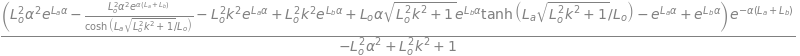


Verification vs boxed formula (should be 0): 0


In [42]:
# Case 2: S = 0, R = 0 (passivated BSI sCMOS)
eta_k_S0 = sp.simplify(eta_k_hyp.subs([(S, 0), (R, 0)]))
print("eta_k (S=0, R=0):")
display(eta_k_S0)

# Verify against the closed-form in the text above
eta_k_S0_expected = alpha * L / (alpha**2 * L**2 - 1) * (
    alpha * L / sp.cosh(xi)
    - sp.tanh(xi) * sp.exp(-alpha * L_a)
    - sp.exp(-alpha * L_a) / (alpha * L)
) - sp.exp(-alpha * L_b)
check = sp.simplify(eta_k_S0.rewrite(sp.exp) - eta_k_S0_expected.rewrite(sp.exp))
print("\nVerification vs boxed formula (should be 0):", check)

### Case 3: Thick Substrate + No Back-Surface Reflection (General $S$)

This is the BSI thick-substrate case of Crowell & Labuda, applicable to **MCT (HgCdTe) infrared detectors** where the absorber substrate is much thicker than the absorption depth ($\alpha L_b \gg 1$).

**Assumptions:**

| Assumption | Parameter change | Physical meaning |
|---|---|---|
| Thick substrate | $L_b \to \infty$ | Carriers generated deep in the substrate recombine before reaching the back surface. The back-surface boundary has no effect. |
| No back-surface reflection | $R = 0$ | Photons reaching the back surface are not reflected back. |
| General surface recombination | $S$ finite | The illuminated surface may be passivated ($S \approx 0$), dead ($S \to \infty$), or anywhere in between. |

**Effect of $L_b \to \infty$:** The only change is that the $-e^{-\alpha L_b}$ tail term vanishes. The rest of $\eta_k$ remains unchanged with general $S$.

**Simplification:** Substituting the hyperbolic forms $\beta_+ + \beta_- = 2\cosh\xi + 2\frac{SL}{D}\sinh\xi$ and $\beta_+ - \beta_- = 2\sinh\xi + 2\frac{SL}{D}\cosh\xi$, the factors of 2 cancel and we can split the fraction:

$$\boxed{\eta_k^{\text{thick}} = \frac{\alpha L}{\alpha^2 L^2 - 1} \left[ \frac{\alpha L + SL/D}{\cosh\xi + (SL/D)\sinh\xi} - \frac{\sinh\xi + (SL/D)\cosh\xi}{\cosh\xi + (SL/D)\sinh\xi} \cdot e^{-\alpha L_a} - \frac{e^{-\alpha L_a}}{\alpha L} \right]}$$

where $\xi = L_a/L$.

#### Sub-case 3a: Dead illuminated surface ($S \to \infty$)

As $S \to \infty$, $SL/D$ dominates and the ratios simplify:

$$\frac{\alpha L + SL/D}{\cosh\xi + (SL/D)\sinh\xi} \;\to\; \frac{1}{\sinh\xi} = \operatorname{csch}\xi, \qquad \frac{\sinh\xi + (SL/D)\cosh\xi}{\cosh\xi + (SL/D)\sinh\xi} \;\to\; \frac{\cosh\xi}{\sinh\xi} = \coth\xi$$


This is **Case 1 without the tail term** — applicable to thick-substrate MCT with dead illuminated surface.

#### Sub-case 3b: Passivated illuminated surface ($S = 0$)

With $SL/D = 0$:

$$\frac{\alpha L + 0}{\cosh\xi + 0} = \alpha L\,\operatorname{sech}\xi, \qquad \frac{\sinh\xi + 0}{\cosh\xi + 0} = \tanh\xi$$

This is **Case 2 without the tail term** — applicable to thick-substrate MCT with passivated illuminated surface.

eta_k (R=0, L_b->inf, general S):


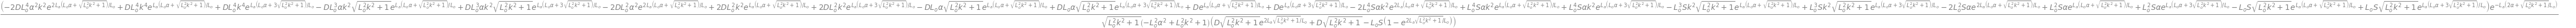


Verification vs boxed formula (should be 0): 0

Sub-case 3a (S->inf) vs Case 1 without tail (should be 0): 0
Sub-case 3b (S=0) vs Case 2 without tail (should be 0): 0


In [43]:
# Case 3: R = 0, L_b -> inf, general S (thick substrate BSI, MCT)
eta_k_thick = sp.limit(eta_k_hyp.subs(R, 0), L_b, sp.oo)
eta_k_thick = sp.simplify(eta_k_thick)
print("eta_k (R=0, L_b->inf, general S):")
display(eta_k_thick)

# Verify against the simplified (split fraction) boxed formula
eta_k_thick_expected = (
    alpha
    * L
    / (alpha**2 * L**2 - 1)
    * (
        (aL + sLD) / (sp.cosh(xi) + sLD * sp.sinh(xi))
        - (sp.sinh(xi) + sLD * sp.cosh(xi))
        / (sp.cosh(xi) + sLD * sp.sinh(xi))
        * sp.exp(-alpha * L_a)
        - sp.exp(-alpha * L_a) / (alpha * L)
    )
)
check = sp.simplify(eta_k_thick.rewrite(sp.exp) - eta_k_thick_expected.rewrite(sp.exp))
print("\nVerification vs boxed formula (should be 0):", check)

# Sub-case 3a: S -> inf (dead surface, thick substrate) = Case 1 without tail
eta_3a = sp.limit(eta_k_thick_expected, S, sp.oo)
eta_3a = sp.simplify(eta_3a)
eta_3a_expected = (
    alpha
    * L
    / (alpha**2 * L**2 - 1)
    * (
        1 / sp.sinh(xi)
        - sp.cosh(xi) / sp.sinh(xi) * sp.exp(-alpha * L_a)
        - sp.exp(-alpha * L_a) / (alpha * L)
    )
)
check_3a = sp.simplify(eta_3a.rewrite(sp.exp) - eta_3a_expected.rewrite(sp.exp))
print("\nSub-case 3a (S->inf) vs Case 1 without tail (should be 0):", check_3a)

# Sub-case 3b: S = 0 (passivated, thick substrate) = Case 2 without tail
eta_3b = sp.simplify(eta_k_thick_expected.subs(S, 0))
eta_3b_expected = (
    alpha
    * L
    / (alpha**2 * L**2 - 1)
    * (
        alpha * L / sp.cosh(xi)
        - sp.tanh(xi) * sp.exp(-alpha * L_a)
        - sp.exp(-alpha * L_a) / (alpha * L)
    )
)
check_3b = sp.simplify(eta_3b.rewrite(sp.exp) - eta_3b_expected.rewrite(sp.exp))
print("Sub-case 3b (S=0) vs Case 2 without tail (should be 0):", check_3b)

## Addendum: Published Models as Special Cases

The reversed geometry (FSI) collection efficiency derived above is:

$$\eta_k^{\text{rev}} = \underbrace{(1 - e^{-\alpha L_D})}_{\text{depletion}} + \underbrace{\eta_{\text{ff},k}}_{\text{field-free diffusion}}$$

with $S \to \infty$ (dead far surface) and $R = 0$. We now show that three well-known published models are recoverable from this single expression.

### Overview of Models

The most general diffusion MTF model is the **Crowell & Labuda (1969)** equation (Eq. 5), which includes surface recombination velocity $S$ at the illuminated surface and back-surface reflectivity $R$. All other models implemented here are special cases or independent re-derivations:

- **Crowell & Labuda (1969) — General form** (Eq. 5): Full model with $S$, $R$, finite field-free region $L_a$, and depletion region $(L_b - L_a)$. Parameters: $\alpha$, $S$, $R$, $L_o$, $L_a$, $L_b$.
- **[Stanford/El Gamal (EE392B)](https://isl.stanford.edu/~abbas/ee392b/lect09.pdf)** — Dead-surface finite model: Independent re-derivation of C&L assuming $S \to \infty$ (dead surface) and $R = 0$ (no back-reflection), with light entering through the depletion region first. Parameters: $\alpha$, $L_D$, $L_{Diff}$, $L$.
- **Seib (1974)** — Semi-infinite special case of C&L: $S \to \infty$, $R = 0$, and $L \to \infty$. Also cited via Fiete and Kopeika. Suitable for thick-substrate CCD and standard CMOS.
- **Shepherd & Day (1982)** — equivalent to Stanford/El Gamal with $L_D = 0$ (no depletion region). Derived independently for MCT infrared detectors.



### Stanford / El Gamal (EE392B)

The Stanford/El Gamal (EE392B, p. 9-14) formula for the FSI geometry with $S \to \infty$ and $R = 0$ is:

$$D(f) = \frac{1 + \alpha L_f - e^{-\alpha L_D}}{1 + \alpha L_f} - \frac{L_f \alpha\, e^{-\alpha L_D}\left(e^{-\alpha L} - e^{-L/L_f}\right)}{(1 - (\alpha L_f)^2)\,\sinh(L/L_f)}$$

where $D(f)$ is the raw collection efficiency, $L_f = L$ is our frequency-dependent diffusion length, and $L = L_a$ is the field-free thickness. The diffusion MTF is $D(f)/D(0)$.

This is **identical** to our reversed-geometry $\eta_k^{\text{rev}}$ — the same model in different notation. No simplification is needed; they are the same derivation (verified symbolically below).

### Fiete-Sieb (Semi-Infinite Substrate)

Taking $L_a \to \infty$ (substrate much thicker than diffusion length), $\sinh\xi \to \infty$ and the field-free boundary term vanishes. The raw collection efficiency becomes:

$$\eta_k^{\text{Sieb}} = 1 - \frac{e^{-\alpha L_D}}{1 + \alpha L}$$

The normalised diffusion MTF is then:

$$\text{MTF}_{\text{diff}}(k) = \frac{\eta_k^{\text{Sieb}}}{\eta_0^{\text{Sieb}}} = \frac{1 - \dfrac{e^{-\alpha L_D}}{1 + \alpha L}}{1 - \dfrac{e^{-\alpha L_D}}{1 + \alpha L_o}}$$

which is exactly the Fiete-Sieb formula used for bulk silicon CCDs and standard CMOS (verified symbolically below).

### Shepherd & Day Dead Surface

Setting $L_D = 0$ (no depletion region — the entire absorber is field-free), the depletion term vanishes and $\eta_k^{\text{rev}}$ reduces to the field-free diffusion contribution alone, with $L_a = d$ (total absorber thickness). This is the Shepherd & Day dead-surface model for MCT infrared detectors (verified numerically below).

In [44]:
# === Stanford/El Gamal: symbolic check ===
stanford = (1 + alpha * L - sp.exp(-alpha * L_D)) / (
    1 + alpha * L
) - L * alpha * sp.exp(-alpha * L_D) * (sp.exp(-alpha * L_a) - sp.exp(-xi)) / (
    (1 - (alpha * L) ** 2) * sp.sinh(xi)
)
check_stanford = sp.simplify((eta_total_k_rev - stanford).rewrite(sp.exp))
print("Stanford/El Gamal check (should be 0):", check_stanford)

# === Fiete-Sieb: symbolic check (L_a -> inf) ===
eta_sieb = sp.limit(eta_total_k_rev, L_a, sp.oo)
eta_sieb = sp.simplify(eta_sieb)

eta_sieb_published = 1 - sp.exp(-alpha * L_D) / (1 + alpha * L)

check_sieb = sp.simplify((eta_sieb - eta_sieb_published).rewrite(sp.exp))
print("Fiete-Sieb (L_a -> inf) check (should be 0):", check_sieb)

# === Shepherd & Day dead surface: numerical check (L_D = 0) ===
import numpy as np


def reversed_geometry_eta(f_arr, alpha_v, L_o_v, L_a_v, L_D_v):
    """Reversed geometry (FSI, S->inf) collection efficiency at frequency f."""
    k_arr = 2 * np.pi * f_arr
    L_v = L_o_v / np.sqrt(1 + k_arr**2 * L_o_v**2)
    xi_v = L_a_v / L_v

    eta_dep = 1 - np.exp(-alpha_v * L_D_v)
    P = alpha_v * L_v**2 / (alpha_v**2 * L_v**2 - 1) * np.exp(-alpha_v * L_D_v)
    A = P * (np.cosh(xi_v) - np.exp(-alpha_v * L_a_v)) / np.sinh(xi_v)
    eta_ff = -(A / L_v - alpha_v * P)  # -D * (...) / D cancels
    return eta_dep + eta_ff


def shepherd_day_dead(f_arr, alpha_v, L_o_v, d_v):
    """Shepherd & Day dead surface raw collection efficiency."""
    2 * np.pi * f_arr
    gamma = np.sqrt(1 / L_o_v**2 + (2 * np.pi * f_arr) ** 2)

    num = gamma * np.sinh(d_v / L_o_v) * (
        np.cosh(gamma * d_v) - np.exp(-alpha_v * d_v)
    ) - alpha_v * np.sinh(d_v / L_o_v) * np.sinh(gamma * d_v)
    den = (1 / L_o_v) * np.sinh(gamma * d_v) * (
        np.cosh(d_v / L_o_v) - np.exp(-alpha_v * d_v)
    ) - alpha_v * np.sinh(gamma * d_v) * np.sinh(d_v / L_o_v)
    raw = (alpha_v**2 - 1 / L_o_v**2) / (alpha_v**2 - gamma**2) * num / den
    return raw


test_cases = [
    ("MWIR 4µm", 1.0, 15.0, 7.0),
    ("LWIR 9µm", 0.15, 25.0, 10.0),
]
f_test = np.linspace(0.01, 33.0, 200)  # cy/mm

print("\nShepherd & Day dead surface vs reversed C&L (L_D=0):")
for label, alpha_v, L_Diff, d in test_cases:
    eta_rev = reversed_geometry_eta(f_test / 1000, alpha_v, L_Diff, d, 0.0)
    mtf_rev = eta_rev / eta_rev[0]

    eta_sd = shepherd_day_dead(f_test / 1000, alpha_v, L_Diff, d)
    mtf_sd = eta_sd / eta_sd[0]

    max_diff = np.max(np.abs(mtf_rev - mtf_sd))
    print(f"  {label}: max |MTF_rev - MTF_SD| = {max_diff:.2e}")

Stanford/El Gamal check (should be 0): 0
Fiete-Sieb (L_a -> inf) check (should be 0): 0

Shepherd & Day dead surface vs reversed C&L (L_D=0):
  MWIR 4µm: max |MTF_rev - MTF_SD| = 3.33e-16
  LWIR 9µm: max |MTF_rev - MTF_SD| = 1.06e-13


### References

- Crowell, M. H. & Labuda, E. F., "The Silicon Diode Array Camera Tube", Bell System Technical Journal, Vol. 48, No. 5, pp. 1481-1528, 1969.
- [El Gamal, A. (Abbas), "EE392B Lecture 9: Spatial Resolution", Stanford University.](https://isl.stanford.edu/~abbas/ee392b/lect09.pdf)
- Seib, D. H., "Carrier Diffusion, Quantum Efficiency, and Modulation Transfer Function in Real-Time Imagers", IEEE Trans. Electron Devices, Vol. 21, No. 3, 1974.
- Day, D. J. & Shepherd, T. J., "Transport in photo-conductors-I: Focal plane processing", Solid-State Electronics, Vol. 25, No. 8, pp. 707-712, 1982.
- Fiete, R. D., "Modeling the Imaging Chain of Digital Cameras", SPIE Tutorial Texts, 2010.
- Kopeika, N. S., "A System Engineering Approach to Imaging", SPIE Press, 1998.